# Task 2: Unemployment Analysis with Python

## Step 1: Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [2]:
df.shape

(768, 7)

In [15]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Year', 'Month'],
      dtype='str')

## Step 2: Null Value Check and Type Conversion

In [4]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [16]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(740, 9)

In [18]:
# Clean up text columns (they also have leading/trailing spaces in some datasets)
for col in ['Region', 'Frequency', 'Area']:
    df[col] = df[col].str.strip()

df['Date'] = df['Date'].str.strip()

# Convert Date column (format is DD-MM-YYYY) to an actual datetime type
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.dtypes

AttributeError: Can only use .str accessor with string values, not datetime64

In [19]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,September


## Step 3: EDA - Region-wise Average Unemployment Rate

In [8]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

## Step 4: EDA - Month-wise Trends

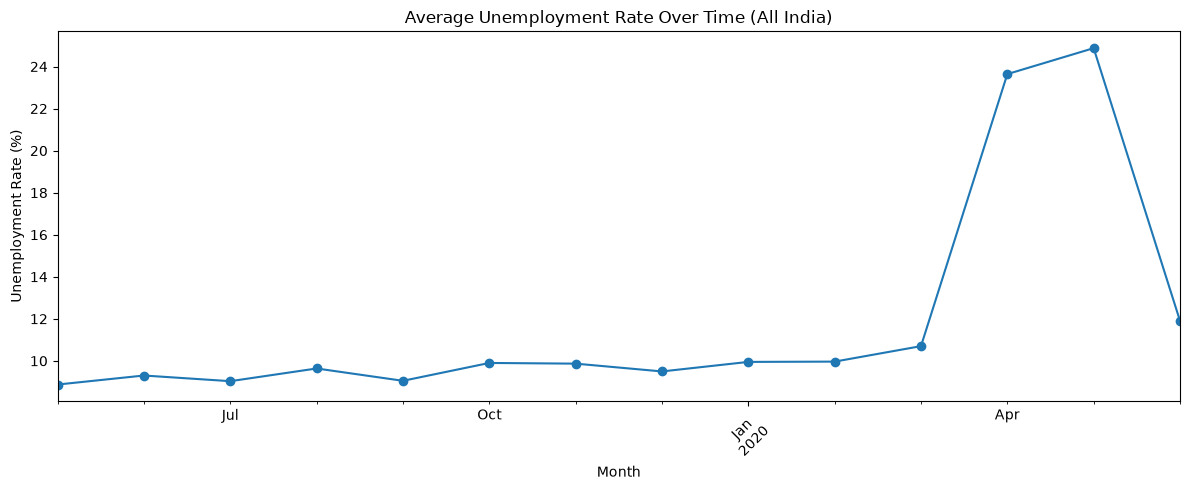

In [9]:
monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,5))
monthly_avg.plot(kind='line', marker='o')
plt.title('Average Unemployment Rate Over Time (All India)')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 5: Time-Series Line Chart - Unemployment Rate Over Time for 3+ States

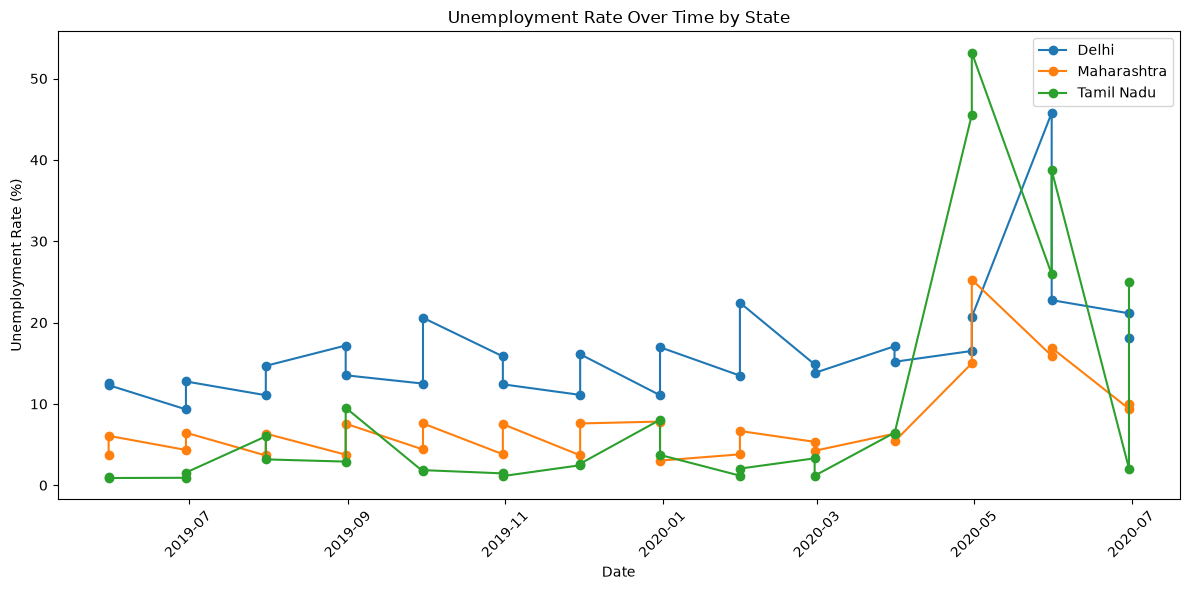

In [10]:
states_to_plot = ['Delhi', 'Maharashtra', 'Tamil Nadu']   # change these to any states present in your data

plt.figure(figsize=(12,6))
for state in states_to_plot:
    state_data = df[df['Region'] == state].sort_values('Date')
    plt.plot(state_data['Date'], state_data['Estimated Unemployment Rate (%)'], marker='o', label=state)

plt.title('Unemployment Rate Over Time by State')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 6: Bar Chart - Top 10 States with Highest Average Unemployment Rate

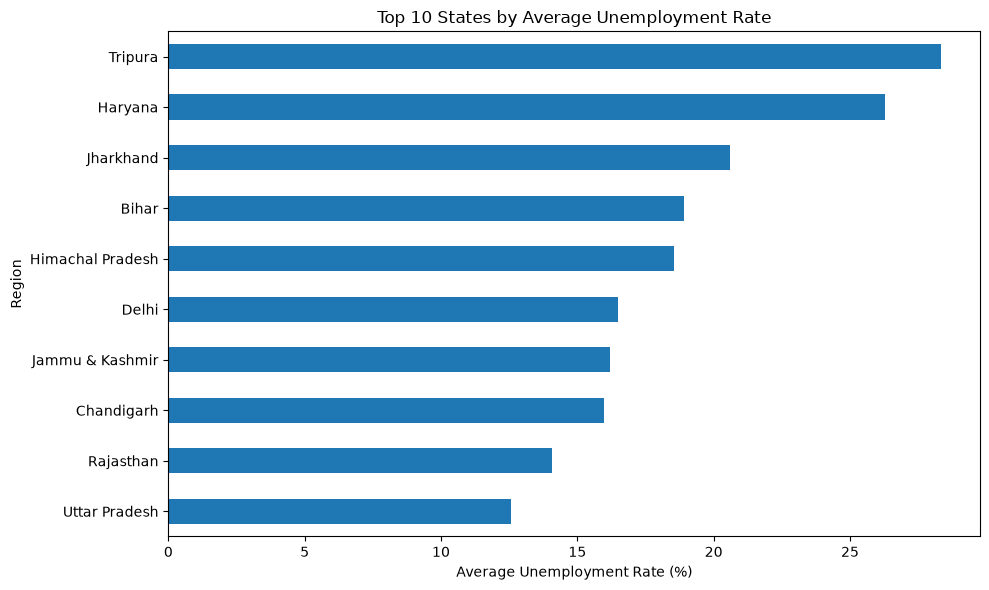

In [11]:
top10 = region_avg.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 7: Correlation Heatmap - Unemployment, Employment, and Labour Participation

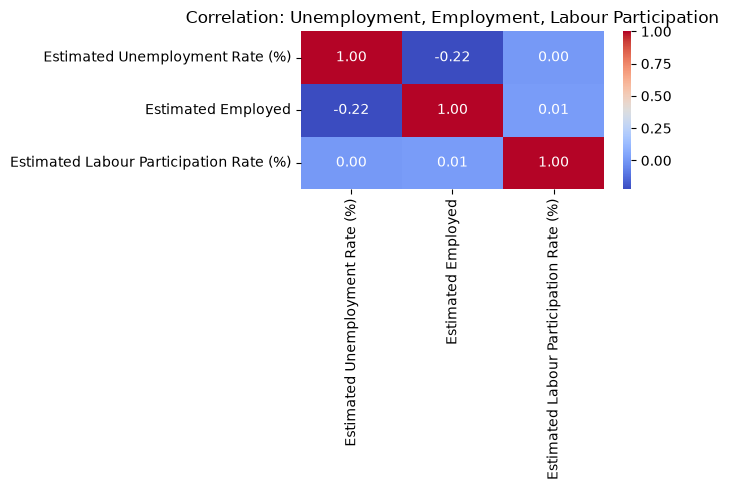

In [12]:
cols_of_interest = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr = df[cols_of_interest].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Unemployment, Employment, Labour Participation')
plt.tight_layout()
plt.show()

## Step 8: Pre-COVID vs. Post-COVID Comparison

In [13]:
covid_start = pd.Timestamp('2020-03-25')

pre_covid = df[df['Date'] < covid_start]
post_covid = df[df['Date'] >= covid_start]

comparison = pd.DataFrame({
    'Pre-COVID': [
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        pre_covid['Estimated Employed'].mean(),
        pre_covid['Estimated Labour Participation Rate (%)'].mean()
    ],
    'Post-COVID': [
        post_covid['Estimated Unemployment Rate (%)'].mean(),
        post_covid['Estimated Employed'].mean(),
        post_covid['Estimated Labour Participation Rate (%)'].mean()
    ]
}, index=['Avg Unemployment Rate (%)', 'Avg Estimated Employed', 'Avg Labour Participation Rate (%)'])

comparison

,Pre-COVID,Post-COVID
Avg Unemployment Rate (%),9.509534e+00,1.777436e+01
Avg Estimated Employed,7.466028e+06,6.517203e+06
Avg Labour Participation Rate (%),4.388612e+01,3.933005e+01


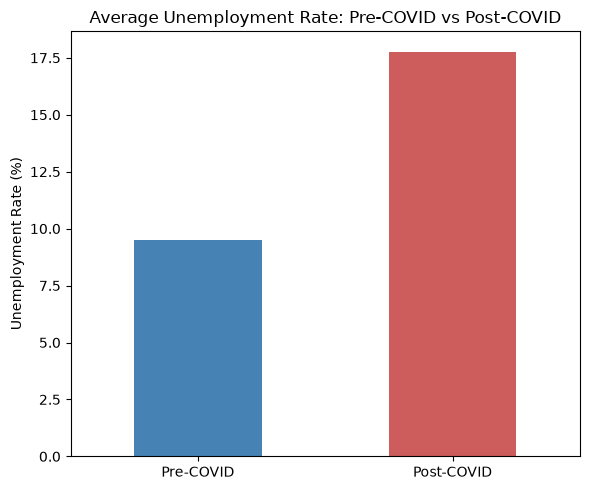

In [14]:
comparison.loc['Avg Unemployment Rate (%)'].plot(kind='bar', figsize=(6,5), color=['steelblue', 'indianred'])
plt.title('Average Unemployment Rate: Pre-COVID vs Post-COVID')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()